In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, skew, mannwhitneyu
import statsmodels.stats.power as smp

In [16]:
# Load the data.
df = pd.read_excel('Time_for_Bac_Fix_Comparison.xlsx')
df.head()

,Chemotaxis,Diffusion
0,19232.0,25479
1,11287.0,23572
2,21931.0,22680
3,19650.0,27111
4,26696.0,27574


### Descriptive Statistics

- Normal Equation: in this case means the unaltered model with both R_a and the conjugation equation.
- No Conj: is the model with R_a but without conjugation.
- No R_a with Conj: is the model without R_a, (bacteria do not slow down in antibiotic), and with conjugation.
- No R_a No Conj: is the model without R_a, and without conjugation.

In [17]:
df.describe()

,Chemotaxis,Diffusion
count,74.000000,100.00000
mean,22122.067568,25490.16000
std,4971.899214,5443.96036
min,11287.000000,6744.00000
25%,19232.000000,22842.50000
50%,21387.000000,25522.50000
75%,24986.000000,28305.00000
max,39176.000000,36457.00000


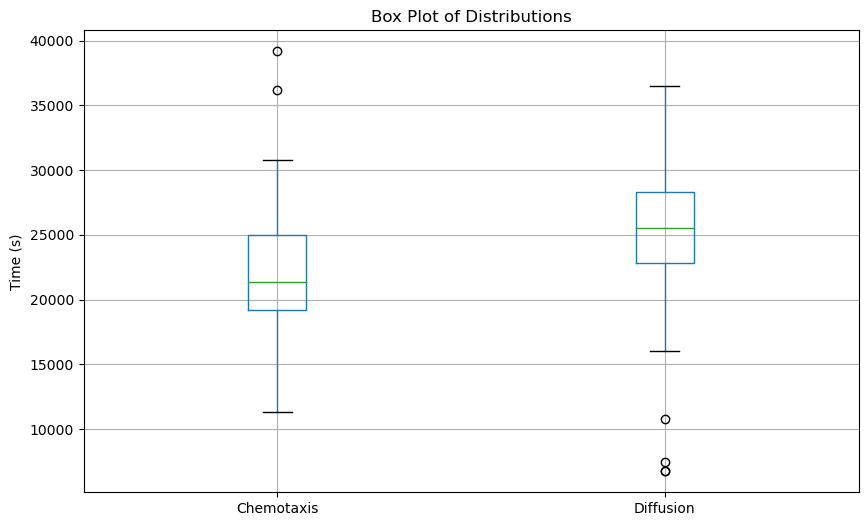

In [18]:
# Step 1: Visualize the Data
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Cleaning

In [19]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Chemotaxis'] = remove_outliers(df, 'Chemotaxis')['Chemotaxis']
df_cleaned['Diffusion'] = remove_outliers(df, 'Diffusion')['Diffusion']
df_cleaned.describe()

,Chemotaxis,Diffusion
count,72.000000,96.000000
mean,21689.555556,26221.177083
std,4281.958542,4155.321960
min,11287.000000,16003.000000
25%,19180.750000,23099.750000
50%,21349.500000,25591.500000
75%,24696.500000,28543.750000
max,30816.000000,36457.000000


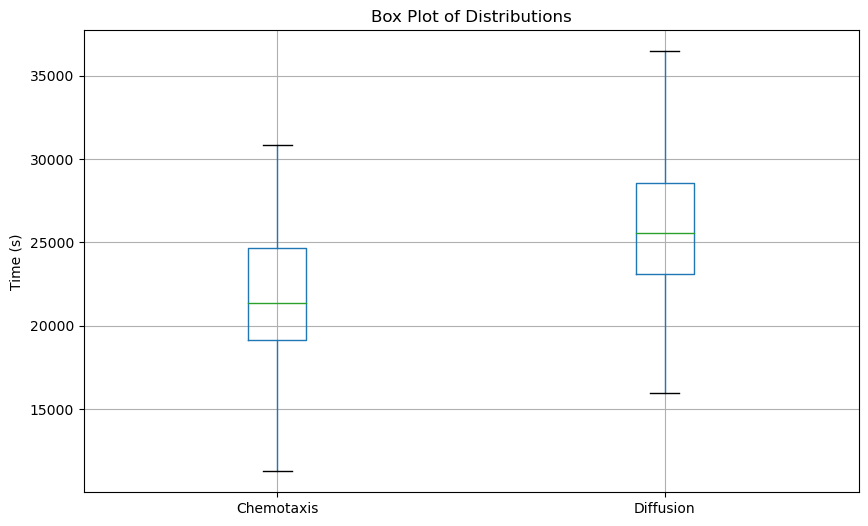

In [20]:
# Visualize the Data
plt.figure(figsize=(10, 6))
df_cleaned.boxplot()
plt.title('Box Plot of Distributions')
plt.ylabel('Time (s)')
plt.show()

### Data Normalization and Histograms

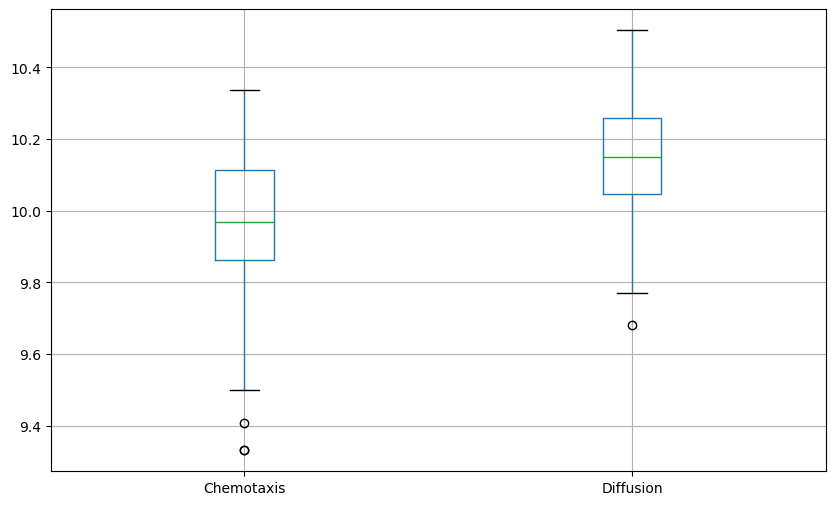

In [26]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Visualize the Data
plt.figure(figsize=(10, 6))
normalized_df_cleaned.boxplot()
plt.show()

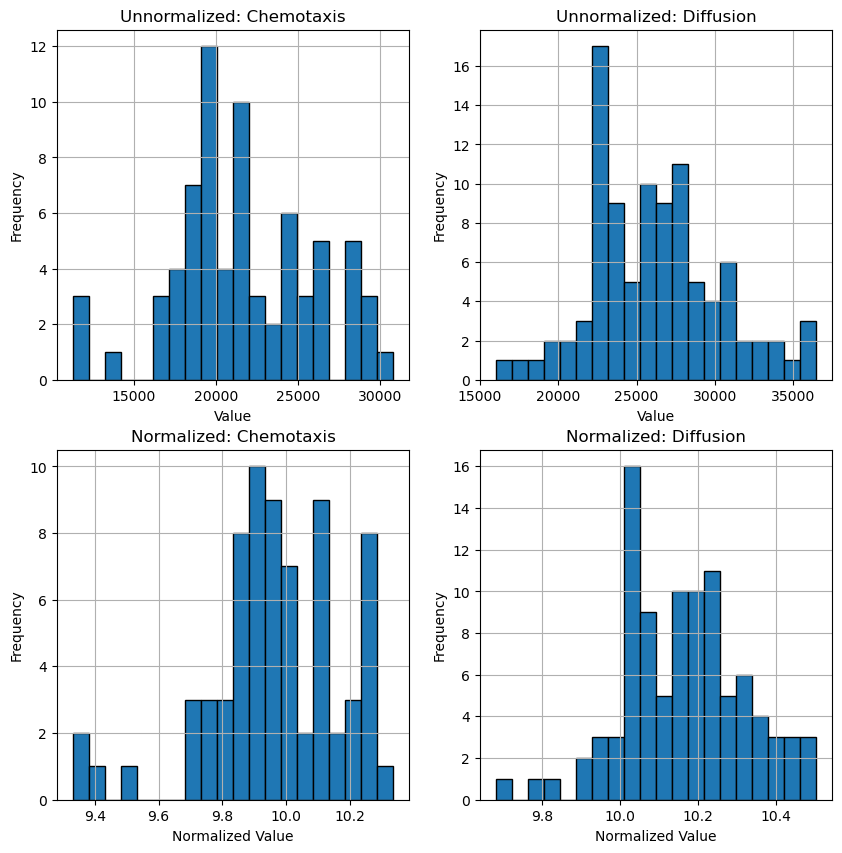

In [22]:
normalized_df_cleaned = df_cleaned.apply(lambda x: np.log(x))

# Number of columns to plot
num_columns = len(df_cleaned.columns)

# Create subplots
fig, axs = plt.subplots(2, num_columns, figsize=(5 * num_columns, 10))

# Ensure axs is 2-dimensional, even if there is only one column
if num_columns == 1:
    axs = np.array([[axs[0]], [axs[1]]])

# Plot histograms for each column in unnormalized data
for i, column in enumerate(df_cleaned.columns):
    df_cleaned[column].hist(ax=axs[0, i], bins=20, edgecolor='k')
    axs[0, i].set_title(f'Unnormalized: {column}')
    axs[0, i].set_xlabel('Value')
    axs[0, i].set_ylabel('Frequency')

# Plot histograms for each column in normalized data
for i, column in enumerate(normalized_df_cleaned.columns):
    normalized_df_cleaned[column].hist(ax=axs[1, i], bins=20, edgecolor='k')
    axs[1, i].set_title(f'Normalized: {column}')
    axs[1, i].set_xlabel('Normalized Value')
    axs[1, i].set_ylabel('Frequency')

### Power Analysis

In [23]:
# Removing Outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Remove outliers
df_cleaned = df.copy()
df_cleaned['Chemotaxis'] = remove_outliers(df, 'Chemotaxis')['Chemotaxis']
df_cleaned['Diffusion'] = remove_outliers(df, 'Diffusion')['Diffusion']
df_cleaned.describe()

,Chemotaxis,Diffusion
count,72.000000,96.000000
mean,21689.555556,26221.177083
std,4281.958542,4155.321960
min,11287.000000,16003.000000
25%,19180.750000,23099.750000
50%,21349.500000,25591.500000
75%,24696.500000,28543.750000
max,30816.000000,36457.000000


**Comparing Normal Equation data to others.**

Comparing the chemotaxis data, (unaltered model), with the diffusion model.

In [24]:
# Calculate Skewness of a data set.
skew_chemotaxis = skew(df['Chemotaxis'].dropna())
skew_diffusion = skew(df['Diffusion'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

skew_chemotaxis, skew_diffusion, u_stat, p_value_u

(0.629558852164571, -1.0111309627711793, 2005.0, 2.493097809421023e-07)

Skewness:
- Both distributions are skewed, as one can tell by their score.
- Chemotaxis: 0.630
- The distribution is slightly skewed to the right.
- Diffusion: -1.011
- The distribution has a skew which goes to the left more.

Median:
- Normal Equation: 21349.5
- No R_a No Conjugation: 25591.5

Mann-Whitney U Test:
- P-value: The the extremely low p-value is less than the common significance level of 0.05.  We can safely conclude that the null hypothesis is rejected and there is significant differences between the two distributions.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing in the 'Normal Equation' more likely to be lower as the median is lower than 'No R_a No Conj'.

In [25]:
# T-Test
t_stat, p_value_u = ttest_ind(df['Chemotaxis'].dropna(), df['Diffusion'].dropna())

t_stat, p_value_u

(-4.184710828106358, 4.546127151903376e-05)

Skewness:
- Both distributions are positively skewed, as one can tell by their score.
- Normal Equation: 1.424
- No R_a with Conj: 0.783
- The smaller score for Normal Equation means the distribution is more skewed and has a longer right tail.

Median:
- Normal Equation: 5001.5
- No R_a with Conj: 6559.0

Mann-Whitney U Test:
- P-value: The p-value of 0.006 is less than the common significance level of 0.05.  We can conclude that the null hypothesis is rejected and there is significant differences between the two distributions.  
- Even given the small sample size there is significant difference after removing the outliers.

Conclusion:
    There is significant differences between the two distributions, and the time for fixing in the 'Normal Equation' more likely to be lower as the median is lower than 'No R_a No Conj'.  While Normal Equation is more skewed, the distribution is more concentrated along a lower time than No R_a with Conj.

**Conclusion:**

    Even with the skew, the 75% percentile for ___ is still lower than 

    The median of ___ is lower than the other distribution.

    The largest factor for the increased varietability hand

**The Remaining Comparisons are not Statistically Significant**

In [13]:
# Normal Equation and No Conj are not statistically significant.
skew_normal = skew(df['Normal Equation'])
skew_no_conj = skew(df['No Conj'].dropna())

# Mann-Whitney U Test
u_stat, p_value_u = mannwhitneyu(df['Normal Equation'], df['No Conj'].dropna())

skew_normal, skew_no_conj, u_stat, p_value_u

(1.4239061887240152, 1.259974694380183, 4515.5, 0.23696428367165434)

In [12]:
# Mann-Whitney U Test for No Conj vs No R_a with Conj
u_stat_no_conj_no_ra_conj, p_value_no_conj_no_ra_conj = mannwhitneyu(df['No Conj'], df['No R_a with Conj'])
u_stat_no_conj_no_ra_conj, p_value_no_conj_no_ra_conj

(4406.5, 0.14735708931203692)

In [11]:
# Mann-Whitney U Test for No Conj vs No R_a No Conj
u_stat_no_conj_no_ra_no_conj, p_value_no_conj_no_ra_no_conj = mannwhitneyu(df['No Conj'], df['No R_a No Conj'])
u_stat_no_conj_no_ra_no_conj, p_value_no_conj_no_ra_no_conj

(4445.0, 0.17546244064801408)

In [10]:
# Mann-Whitney U Test for No R_a with Conj vs No R_a No Conj
u_stat_no_ra_conj_no_ra_no_conj, p_value_no_ra_conj_no_ra_no_conj = mannwhitneyu(df['No R_a with Conj'], df['No R_a No Conj'])
u_stat_no_ra_conj_no_ra_no_conj, p_value_no_ra_conj_no_ra_no_conj

(5129.5, 0.7526118671123978)

### Sample Sizes

In [35]:
# Calculate pooled standard deviation
n1 = df.shape[0]
n2 = df['No R_a No Conj'].dropna().shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_no_conj**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

In [36]:
# Perform power analysis
alpha = 0.05
power = 0.80

analysis = smp.NormalIndPower()
required_sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

effect_size, required_sample_size

(0.11773745591169878, 1132.4194266886839)

In [13]:
# Calculate pooled standard deviation
n1 = n2 = df.shape[0]
s_p = np.sqrt(((n1 - 1) * std_normal**2 + (n2 - 1) * std_no_Ra_w_conjugation**2) / (n1 + n2 - 2))

# Calculate Cohen's d, (the effect size in power analysis to find required sample size using this sample data).
effect_size = abs(mean_normal - mean_no_Ra_w_conjugation)/s_p

Power Analysis Inputs:
- Effect size (Cohen's d): Use the effect size estimated from the pilot study.
- Significance level (α): Typically set at 0.05.
- Power (1 - β): Commonly set at 0.80 or 0.90.
- Two-tailed test: If you are interested in differences in both directions.